# Exploring the Global All-Cap Universe with a single call to the Batch Search API

**One job, one upload, one download — 10,000 companies in a single batch call.**

Traditional RAG and search workflows are built for a handful of entities at a time: you point at a few tickers or names, run a query, get results. Scaling to a full universe (e.g. Global All-Cap, ~10,000 names) means orchestrating thousands of HTTP requests — per-query rate limits (QPS), connection pools, retries, backoff, and timeouts become your problem. You either throttle down and wait, or you push QPS and risk 429s and failed runs. The **Batch Search API** removes that entirely: you submit **one file** with up to 1,000 queries; the service processes them asynchronously and returns one result file. No client-side loops, no QPS management, no thousands of round-trips. 

**Use case.** We ask how the **Global All-Cap universe** (10,000 companies) have been affected by Trump administration policies over a recent window (e.g. the last six months). The goal is a ranked list of top-affected names and bottom-up macro signals—a sector–country heatmap—grounded in document-level evidence.

**What this notebook does.** We (1) set up dependencies and load the universe from a CSV; (2) configure topic and time range; (3) build 1,000 queries (10 entities per query); (4) submit a single batch job to the **Batch Search API** (create, upload JSONL, poll, download); (5) post-process with by-query chunk assignment and aggregate scores; (6) show top positive and negative companies plus top chunks for the most negative; (7) build a sector–country heatmap as a bottom-up macro indicator.

**Topic:** *"The company is affected by the Trump administration's policies."* (Configurable in section 3.)



## 1. Setup

Load dependencies and paths. Authentication uses **BIGDATA_API_KEY** from `.env`. We also define where the universe CSV and result files live.

In [1]:
import os
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Load .env from current directory (run notebook from Batch_Search_API folder)
load_dotenv(".env")

# Import the batch API client (run from Batch_Search_API folder)
import sys
sys.path.insert(0, str(Path(".").resolve()))
from src.batch_api_client import BatchAPIClient, poll_until_complete, MetricsTracker

# Paths
NOTEBOOK_DIR = Path(".").resolve()
CSV_PATH = NOTEBOOK_DIR / "global_all_caps.csv"
G12_COUNTRIES_BY_PLOT_PATH = NOTEBOOK_DIR / "g12_countries_by_plot.csv"
RESULTS_DIR = NOTEBOOK_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

## 2. Load the Global All-Cap universe

Read the universe CSV. Columns **RP_ENTITY_ID**, **COMPANY_NAME**, **COUNTRY**, **SECTOR** are used to build queries (10 entities per query) and later to join results for the sector–country heatmap.

In [2]:
df_universe = pd.read_csv(CSV_PATH)
# CSV column is RP_COMPANY_ID; rename to RP_ENTITY_ID (the Bigdata entity ID used in API calls),
# matching the name used throughout the rest of this notebook.
df_universe = df_universe.rename(columns={"RP_COMPANY_ID": "RP_ENTITY_ID"})
print(f"Loaded {len(df_universe):,} companies. Columns: {list(df_universe.columns)}")

# Demo mode: run against a small, well-known set of ~5 companies instead of the full
# ~10k Global All-Cap universe, so the batch job finishes quickly. For production,
# comment out this line to use the full universe loaded above.
DEMO_ENTITY_IDS = ["D8442A", "228D42", "0157B1", "E09E2B", "DD3BB1"]  # Apple, Microsoft, Amazon, NVIDIA, Tesla
df_universe = df_universe[df_universe["RP_ENTITY_ID"].isin(DEMO_ENTITY_IDS)].reset_index(drop=True)
print(f"Demo universe: {len(df_universe)} companies.")
df_universe.head(10)

Loaded 10,000 companies. Columns: ['RP_ENTITY_ID', 'COMPANY_NAME', 'COUNTRY', 'SECTOR']
Demo universe: 5 companies.


,RP_ENTITY_ID,COMPANY_NAME,COUNTRY,SECTOR
0,DD3BB1,Tesla Inc.,United States,Consumer Goods
1,E09E2B,NVIDIA Corp.,United States,Technology
2,D8442A,Apple Inc.,United States,Technology
3,0157B1,Amazon.com Inc.,United States,Consumer Services
4,228D42,Microsoft Corp.,United States,Technology


## 3. Configuration: topic and time range

Set the **search topic** (e.g. Companies affected by the Trump administration's policies) and the **time window** (ISO timestamps). These are applied to every query in the batch.

In [3]:
TOPIC = "The company is affected by the Trump administration's policies"

from datetime import datetime, timedelta

TIME_END = datetime.now()
TIME_START = (TIME_END - timedelta(days=7)).strftime("%Y-%m-%dT%H:%M:%S")
TIME_END = TIME_END.strftime("%Y-%m-%dT%H:%M:%S")

print(f"Topic: {TOPIC}")
print(f"Time range: {TIME_START} to {TIME_END}")


Topic: The company is affected by the Trump administration's policies
Time range: 2026-08-07T09:04:18 to 2026-08-14T09:04:18


## 4. Build queries

Here, we generate one query per group of 10 companies from the universe, using **entity.any_of** to provide the list of entity IDs. Each query uses the same topic, filters and time window.

For a universe of 10,000 companies, this approach yields 1,000 total queries, all sent together in a single batch job. In principle, it is also possible to generate one query per company and submig 10,000 queries. However, this can substantially increase total latency and will result in many searches returning empty results, since many smaller companies may see relatively little news coverage or hits for the given topic. Here, the batching of entities is performed sequentially in CSV row order. However, an optimal approach would be to group companies with similar levels of media attention together within each batch. This avoids having companies with high visibility dominate ("drown out") companies with less coverage, thereby giving smaller or less-publicized companies a better chance of returning relevant results.

The filter settings chosen here aim to increase precision: we include an entity control filter for Trump (*22C3AF*) and set the reranker threshold at 0.7, which together favor more relevant results but may reduce recall by filtering out potentially relevant chunks.
Alternative large-scale applications may opt for higher recall, compensating later by applying verification via LLMs in post-processing. In this notebook, we focus on clarity and simplicity, so we do not use any LLM-based judgment layers.

In [4]:
ENTITIES_PER_QUERY = 10  # Pack 10 entities per query → 1,000 queries for 10k companies
MAX_CHUNKS_PER_QUERY = 50

def build_query(entity_ids: list, topic: str, time_start: str, time_end: str, max_chunks: int = 100) -> dict:
    """Build one search query for a list of entity IDs (any_of)."""
    return {
        "auto_enrich_filters": False,
        "text": topic,
        "filters": {
            "timestamp": {"start": time_start, "end": time_end},
            "entity": {"any_of": entity_ids, "all_of": ["22C3AF"]}
        },
        "ranking_params": {"source_boost": 0, "freshness_boost": 0, "reranker": {"enabled": True, "threshold": 0.7}},
        "max_chunks": max_chunks,
    }

# Slice universe in chunks of 10; one query per chunk (same order as df_universe)
n = len(df_universe)
queries = []
for start in range(0, n, ENTITIES_PER_QUERY):
    chunk = df_universe.iloc[start : start + ENTITIES_PER_QUERY]
    entity_ids = chunk["RP_ENTITY_ID"].astype(str).tolist()
    queries.append(build_query(entity_ids, TOPIC, TIME_START, TIME_END, MAX_CHUNKS_PER_QUERY))
query_lines = [{"query": q} for q in queries]
num_queries = len(query_lines)
print(f"Total queries: {num_queries:,} (each with {ENTITIES_PER_QUERY} entities) → one batch job")
print(f"Sample query: {query_lines[0]['query']}")

Total queries: 1 (each with 10 entities) → one batch job
Sample query: {'auto_enrich_filters': False, 'text': "The company is affected by the Trump administration's policies", 'filters': {'timestamp': {'start': '2026-08-07T09:04:18', 'end': '2026-08-14T09:04:18'}, 'entity': {'any_of': ['DD3BB1', 'E09E2B', 'D8442A', '0157B1', '228D42'], 'all_of': ['22C3AF']}}, 'ranking_params': {'source_boost': 0, 'freshness_boost': 0, 'reranker': {'enabled': True, 'threshold': 0.7}}, 'max_chunks': 50}


## 5. Submit one batch job

 This section handles the end-to-end process of submitting a batch search job to the API. 
 The steps are as follows:
 - First, a new batch job is created on the API, which returns both a batch job ID and a presigned URL to upload the queries.
 - Next, the queries (packed as a JSONL string) are uploaded using the provided URL.
 - After uploading, a polling loop is started that regularly checks the status of the batch job until it is marked complete.
 - Once the job completes, the final output location is extracted from the API's status response.
 - The code then downloads the results directly from the provided URL and saves them to disk in the `results/` directory, using a filename based on the batch ID.
 
 Note: This workflow assumes all queries are uploaded at once and that the batch API will handle them asynchronously. There are no additional rate limiting or loop constructs on the client side; the server-side batching is responsible for resource throttling and progress management.

In [5]:
api_key = os.getenv("BIGDATA_API_KEY")
if not api_key:
    raise ValueError("Set BIGDATA_API_KEY in .env")

jsonl_content = ("\n".join(json.dumps(line) for line in query_lines) + "\n").encode("utf-8")

client = BatchAPIClient(
    base_url="https://api.bigdata.com",
    api_key=api_key,
)
try:
    batch_id, presigned_url, _ = client.create_batch_job()
    print(f"Created batch: {batch_id}")
    client.upload_queries_file(presigned_url, jsonl_content)
    print(f"Uploaded {num_queries:,} queries.")
    metrics = MetricsTracker(batch_id, num_queries)
    status_data = poll_until_complete(client, batch_id, metrics, poll_interval=15)
    # Expected results path (for post-processing); always set from batch_id
    RESULTS_PATH = RESULTS_DIR / f"batch_{batch_id}_results.jsonl"
    # Extract output URL (same logic as batch_api_client: unwrap data, string body, try multiple keys)
    data = status_data.get("data") if isinstance(status_data.get("data"), dict) else status_data
    if isinstance(data.get("body"), str):
        try:
            data = json.loads(data["body"])
        except json.JSONDecodeError:
            pass
    output_file = (
        data.get("outputFile") or data.get("output_file")
        or data.get("resultFile") or data.get("result_file")
        or {}
    )
    output_url = output_file.get("url") if isinstance(output_file, dict) else None
    if not output_url:
        output_url = (
            data.get("downloadUrl") or data.get("download_url")
            or data.get("output_file_url") or data.get("outputFileUrl")
        )
    if output_url:
        results_bytes, _ = client.download_results(output_url)
        RESULTS_PATH.write_bytes(results_bytes)
        print(f"Results saved: {RESULTS_PATH}")
    else:
        print("No output URL in status response; results not downloaded.")
        print(f"For post-processing, expected path: {RESULTS_PATH}")
        # Debug: print actual response so we can fix parsing (API may use different keys)
        print("Status response keys (top-level):", list(status_data.keys()))
        print("Unwrapped 'data' keys:", list(data.keys()) if isinstance(data, dict) else "N/A")
        print("Full status response (for parsing fix):")
        print(json.dumps(status_data, indent=2)[:1200])
finally:
    client.close()

Created batch: 8d82bc58-03a5-4dcb-8eff-35e9d6fb5e9e


Uploaded 1 queries.
Polling for batch job completion (batch_id: 8d82bc58-03a5-4dcb-8eff-35e9d6fb5e9e)...
Poll interval: 15 seconds



[09:04:30] Status: PROCESSING | Elapsed: 0s


[09:04:46] Status: PROCESSING | Elapsed: 20s


[09:05:03] Status: PROCESSING | Elapsed: 37s


...

[09:08:39] Status: PROCESSING | Elapsed: 4m 13s


[09:08:56] Status: PROCESSING | Elapsed: 4m 30s


[09:09:13] Status: PROCESSING | Elapsed: 4m 46s


[09:09:29] Status: COMPLETED | Elapsed: 5m 3s

✓ Batch job completed successfully!


Results saved: /Users/bakulkumarkakadiya/dev/github/cookbook-master/bigdata-cookbook/Batch_Search_API/results/batch_8d82bc58-03a5-4dcb-8eff-35e9d6fb5e9e_results.jsonl


## 6. Post-processing: deduplicate chunks, entity detections, join to universe, aggregate

 In this step, we post-process the batch API results to obtain entity-level metrics for downstream analysis. 
 Our goal is to efficiently combine both the quantity of media attention for each entity (i.e., how many relevant 
 chunks mention it) and the qualitative sentiment of those mentions. This is achieved by first deduplicating 
 the extracted "chunks" (text passages) by their unique identifiers—specifically, each `(doc_id, cnum)` pair, 
 which ensures we only count each unique passage once. 

We assign each chunk only to entities that were in the **query's** `entity.any_of` for the response line that returned that chunk—and that also appear in the chunk's detections and in our universe. We then cross-reference those entity ids with our universe to attach SECTOR, COUNTRY, and COMPANY_NAME. This avoids *co-mention bias*: each chunk contributes only to the entities we asked about in that query.

 We then construct a "long table" representation: each row represents a pairing between a single chunk and a detected entity, along with the associated `relevance` and `sentiment` scores for that detection.

The core step in this process is aggregating the results at the entity level by constructing a single metric we call "score." 
 This score is designed to capture not just how many times an entity is mentioned, but also the nature of those mentions.
 For each entity, we add up the sentiment score for every chunk in which it appears, but we weight each contribution by its relevance to the search.
 In mathematical terms, we sum (sentiment × relevance) across all associated chunks. This approach lets us identify entities that not only receive significant media attention (volume), but whose coverage skews more positive or negative overall—and it gives extra weight to mentions that are especially pertinent to our search theme.
 The resulting score is not normalized, but because it is bounded by the total number of retrieved chunks, we can still meaningfully compare one entity’s score against another’s within this batch.
 In short: this aggregation method answers both "how much" and "how strongly" each entity is covered in the media, all in a single number.

 The final result is a "wide table": one row per entity (for all entities appearing in at least one chunk),
 including the overall score and the attached metadata (sector, country, company name).
 This approach allows for generating meaningful visualizations (such as sector-country heatmaps) where
 the aggregate score in each cell reflects both the strength and the breadth of media attention, in units 
 weighted by relevance. Note that because we sum (not average) sentiment × relevance, the resulting 
 scores are unbounded—they reflect total weighted sentiment, not a simple mean.

In [6]:
try:
    path_to_use = RESULTS_PATH
except NameError:
    path_to_use = None
if path_to_use is None or not Path(path_to_use).exists():
    result_files = sorted(RESULTS_DIR.glob("batch_*_results.jsonl"), key=lambda p: p.stat().st_mtime, reverse=True)
    path_to_use = result_files[0] if result_files else None
if path_to_use is None:
    raise FileNotFoundError("No batch results found. Run the batch job cell above first.")

universe_ids = set(df_universe["RP_ENTITY_ID"])
long_rows = []
seen = set()  # (entity_id, doc_id, cnum) for deduping

with open(path_to_use) as f:
    for line_idx, line in enumerate(f):
        rec = json.loads(line)
        q = query_lines[line_idx].get("query", {}) if line_idx < len(query_lines) else {}
        query_ids = {str(e) for e in ((q.get("filters") or {}).get("entity") or {}).get("any_of") or []}
        for doc in rec.get("response", {}).get("results") or rec.get("results") or []:
            doc_id = doc.get("id", "")
            for ch in doc.get("chunks") or []:
                rel, sent, cnum = ch.get("relevance"), ch.get("sentiment"), ch.get("cnum")
                if rel is None or sent is None:
                    continue
                for d in ch.get("detections") or []:
                    if d.get("type") != "entity" or not (eid := d.get("id")) or eid not in universe_ids or eid not in query_ids:
                        continue
                    key = (eid, doc_id, cnum)
                    if key not in seen:
                        seen.add(key)
                        long_rows.append({"entity_id": eid, "relevance": rel, "sentiment": sent})

print(f"Entity–chunk pairs: {len(long_rows)}")

df_long = pd.DataFrame(long_rows)
if df_long.empty:
    entity_agg = pd.DataFrame(columns=["RP_ENTITY_ID", "score", "volume"])
else:
    # 5–6. Aggregate per entity: score = sum(sentiment × relevance), volume = chunk count (no division)
    entity_score = df_long.groupby("entity_id").apply(lambda g: (g["sentiment"] * g["relevance"]).sum(), include_groups=False).rename("score")
    entity_volume = df_long.groupby("entity_id").size().rename("volume")
    entity_agg = pd.concat([entity_score, entity_volume], axis=1).reset_index()
    entity_agg = entity_agg.rename(columns={"entity_id": "RP_ENTITY_ID"})
    entity_agg["volume"] = entity_agg["volume"].fillna(0).astype(int)
    entity_agg["score"] = entity_agg["score"].fillna(0.0)
df_metrics = entity_agg.merge(df_universe[["RP_ENTITY_ID", "COMPANY_NAME", "SECTOR", "COUNTRY"]], on="RP_ENTITY_ID", how="inner")
df_metrics = df_metrics[["RP_ENTITY_ID", "score", "volume", "COMPANY_NAME", "SECTOR", "COUNTRY"]]
print(f"Loaded {len(df_metrics)} entities with sector/country (with at least one chunk).")


Entity–chunk pairs: 39
Loaded 5 entities with sector/country (with at least one chunk).


### Top 5 positive and top 5 negative by score
A single, broad topic prompt was enough to surface 1,847 companies (19% of the top 10,000 publicly listed globally) in chunks linked to Trump policies, illustrating the approach’s value for global screening. To illustrate the most notable cases, we showcase the top 5 positive and top 5 negative entities in terms of score. The chart below presents these results, with the five most negative scores (shown in red, on the left) and the five most positive scores (shown in green, on the right). The score for each company is calculated by summing the product of sentiment and relevance across all its chunks.



findfont: Failed to find font weight 500, now using 400.


findfont: Failed to find font weight 600, now using 700.


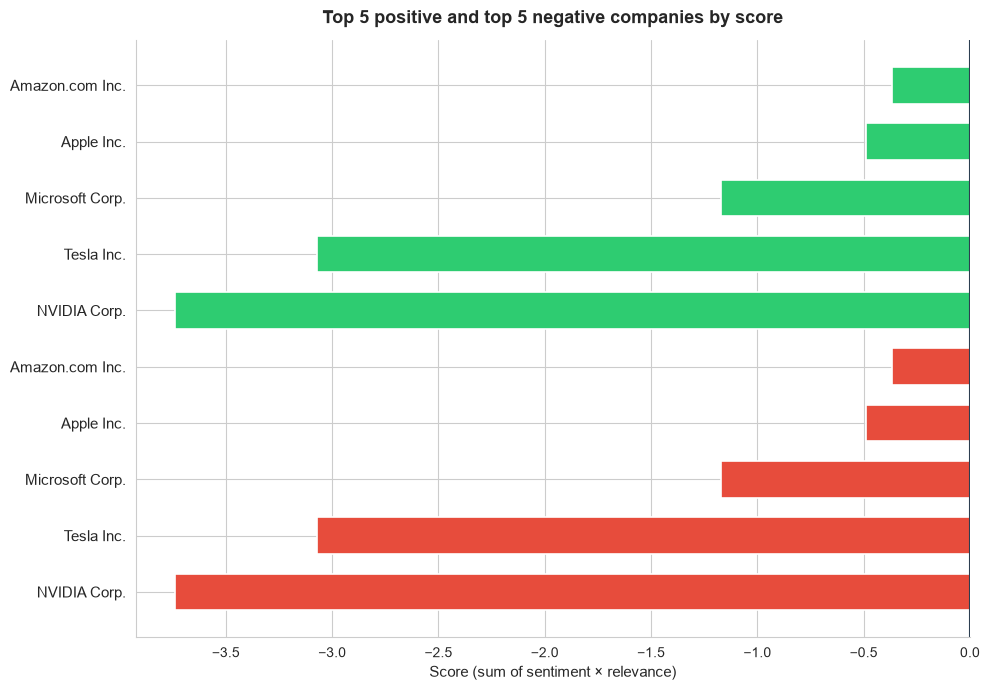

In [7]:
# Combined plot: top 5 positive and top 5 negative (diverging bar chart)
top5_neg = df_metrics.nsmallest(5, "score")[["COMPANY_NAME", "score"]].reset_index(drop=True)
top5_pos = df_metrics.nlargest(5, "score")[["COMPANY_NAME", "score"]].reset_index(drop=True)
combined = pd.concat([top5_pos, top5_neg.iloc[::-1]], ignore_index=True)
labels = combined["COMPANY_NAME"].tolist()
scores = combined["score"].tolist()

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(labels))
bar_height = 0.65
bars = ax.barh(y_pos, scores, height=bar_height, color=["#2ecc71"] * 5 + ["#e74c3c"] * 5, edgecolor="white", linewidth=1.2)
ax.axvline(0, color="#2c3e50", linewidth=1.5, linestyle="-", zorder=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11, fontweight=500)
ax.set_xlabel("Score (sum of sentiment × relevance)", fontsize=11)
ax.set_title("Top 5 positive and top 5 negative companies by score", fontsize=13, fontweight=600, pad=12)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Top chunks for the most negative company

To explore in more detail what is underlying the scores, here we select and display the top chunks (ranked by relevance) for the company with the lowest aggregate score. Each row shows the full chunk text, along with the relevance and sentiment scores for that chunk. Note that sentiment is computed at the chunk level; additional weighting or advanced techniques can be applied to improve entity-level accuracy and interpretability. 

In [8]:
# Top chunks for most negative company 
pd.set_option("display.max_colwidth", None)
most_neg = df_metrics.loc[df_metrics["score"].idxmin()]
targets = {most_neg["RP_ENTITY_ID"]: most_neg["COMPANY_NAME"]}
TOP_N_CHUNKS = 5
best_by_text = {}  # (entity_id, chunk_text) -> row; keep highest impact per unique text

with open(path_to_use) as f:
    for line_idx, line in enumerate(f):
        rec = json.loads(line)
        q = query_lines[line_idx].get("query", {}) if line_idx < len(query_lines) else {}
        query_ids = {str(e) for e in ((q.get("filters") or {}).get("entity") or {}).get("any_of") or []}
        for doc in rec.get("response", {}).get("results") or rec.get("results") or []:
            doc_source = (doc.get("source") or {}).get("name", "")
            doc_ts = doc.get("timestamp") or ""
            doc_date = doc_ts[:10] if isinstance(doc_ts, str) and len(doc_ts) >= 10 else doc_ts
            for ch in doc.get("chunks") or []:
                text = ch.get("text", "")
                rel, sent = ch.get("relevance"), ch.get("sentiment")
                if rel is None or sent is None:
                    continue
                for d in ch.get("detections") or []:
                    if d.get("type") != "entity":
                        continue
                    eid = d.get("id")
                    if not eid or eid not in targets or eid not in query_ids:
                        continue
                    impact = abs(rel * sent)
                    key = (eid, text)
                    if key not in best_by_text or rel > best_by_text[key]["relevance"]:
                        best_by_text[key] = {
                            "company": targets[eid],
                            "chunk": text,
                            "relevance": rel,
                            "sentiment": sent,
                            "impact": impact,
                            "entity_id": eid,
                            "source": doc_source,
                            "date": doc_date,
                        }
                    break

chunk_rows = list(best_by_text.values())

df_chunks = pd.DataFrame(chunk_rows)
if df_chunks.empty:
    print("No chunks found for the most positive/negative companies.")
else:
    df_chunks = df_chunks.sort_values("relevance", ascending=False)
    for entity_id, name in targets.items():
        sub = df_chunks[df_chunks["entity_id"] == entity_id].head(TOP_N_CHUNKS)
        if sub.empty:
            continue
        print(f"\n### {name} (top {TOP_N_CHUNKS} chunks)\n")
        display(sub[["source", "date", "chunk", "relevance", "sentiment"]])


### NVIDIA Corp. (top 5 chunks)



,source,date,chunk,relevance,sentiment
0,CNBC,2026-08-13,"They highlighted 15 instances of what they said were examples of Trump buying stock in a company prior to an official government announcement favorable to that company.\nThey include purchases of Nvidia and Advanced Micro Devices on Jan. 6, one week before the Trump administration announced loosened export controls that would ""make it easier to sell AMD and NVIDIA chips to China,"" according to the lawmakers.\nThey also pointed to Trump's Feb. 10 purchase of between $1 million and $5 million of stock in Taser-maker Axon Enterprises, two weeks before Immigration and Customs Enforcement unveiled a $220 million Taser contract. Experts told CNBC in June that the contract appeared tailored to Axon's products.\nThe letter further questions certain sales of Microsoft and Meta stock.",0.701057,-0.43
1,The Globe And Mail,2026-08-07,"Missed Nvidia in 2009? This Rare Signal Is Flashing Again. In 2009, a ""Double Down"" signal flashed for a little-known chipmaker called Nvidia. For the first time in years, that same ""Total Conviction"" signal is flashing for a company 1/100th the size of Nvidia.\nThe Trump administration is issuing up to $166 billion in tariff refunds. Image source: Official White House Photo by Patrick B. Ruddy.\nBut in the days following this announcement, the Dow, S&P 500, and Nasdaq Composite endured what's now known as the ""tariff tantrum."" Equities plunged amid historic uncertainty\nBy February 2026, the U.S. Supreme Court had invalidated the tariffs that Donald Trump had imposed under the International Emergency Economic Powers Act (IEEPA). This left the Trump administration on the hook to refund approximately $166 billion in IEEPA tariffs it had collected. On Aug. 4, total refunds issued surpassed $100 billion.",0.687293,-0.34
2,Kabutan,2026-08-10,"Semiconductor manufacturer Intel (INTC) fell after disclosing plans to raise $15 billion through stock issuance to expand its semiconductor foundry business. Semiconductor manufacturer Nvidia (NVDA) declined due to concerns after announcing it would raise $500 billion from six financial institutions for AI infrastructure investment. GameStop (GME), a video game retailer, fell on reports that it is considering withdrawing its acquisition offer for e-commerce company eBay (EBAY). eBay (EBAY) also declined.\nPresident Trump asserted that the United States has 100% control over the Strait of Hormuz.\n(Horiko Capital Management LLC)\nand the possibility of canceling plans to develop high-end models that adopt the system, leading to an expected sales decline.",0.652186,-0.78
3,Fresno Bee,2026-08-12,"The Trump administration has engaged in an unprecedented campaign of government meddling in business affairs. It has leveraged the threat of regulatory consequences to press dozens of private companies into giving the government equity stakes in their businesses, from semiconductors and nuclear energy to minerals and steel, as The New York Times has reported. A shareholder of Intel has already brought a lawsuit claiming that the Trump administration secured its 10% stake in that tech company through extortion.\nIn each of these cases, the federal government is now both the regulator and a shareholder, raising questions about whether commercial competitors in important U.S. industries still have a level playing field and whether regulatory action will continue in the interest of the public or of profitability. As one example, the price for regulatory approval of Nvidia's advanced chip sale to China was to give a cut of the revenue to the government. Trump may gloat about the earnings, but that did nothing to address the very real national security concerns with handing our greatest adversary a leg up in the artificial intelligence race.",0.601444,-0.76
4,MINKABU,2026-08-10,Semiconductor manufacturer Intel (INTC) fell after revealing plans to raise $15 billion through stock issuance to expand its semiconductor contract ma

## 7. Bottom-up Macro Indicators

The large-scale batch is especially powerful here. We aggregate entity-level scores into bottom-up macro indicators by sector and country. For this example, we build a heatmap using **all sectors** and a **G12 selection of countries** from `g12_countries_by_plot.csv`. Each cell shows the **sum(score)** over entities in that sector–country. Color scale: blue = negative, white = neutral, red = positive.

For our topic, "how companies are affected by the Trump administration's policies", this heatmap surfaces which sector–country combinations are most negatively or positively associated with media coverage and sentiment. Sectors and countries with strongly negative scores may indicate higher exposure to regulatory, tariff, or policy risk; strongly positive ones may reflect perceived benefits or resilience. The view is built from entity-level evidence rather than pre-aggregated statistics, so it remains grounded in the underlying documents and chunks returned by the Batch API.


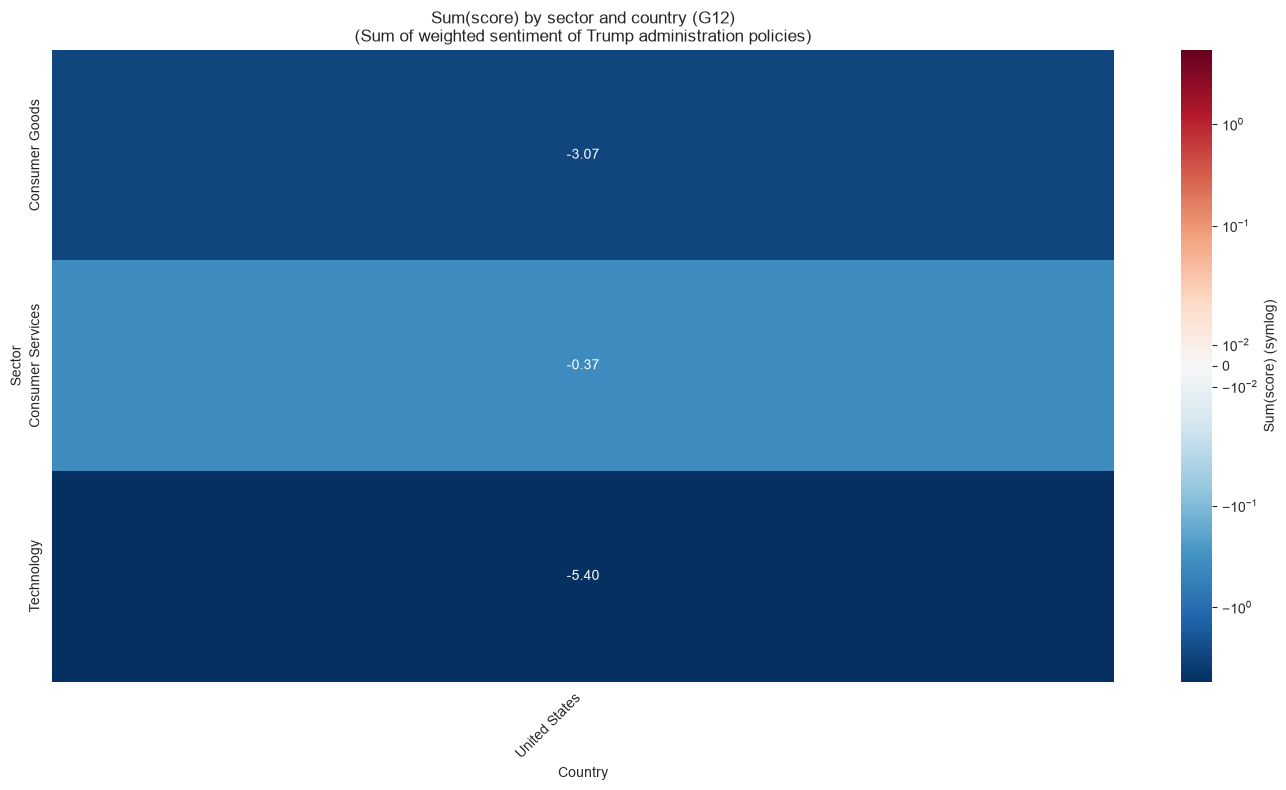

In [9]:
# All sectors (from universe); G12 countries; sum(score) per sector × country
import numpy as np
from matplotlib.colors import SymLogNorm

all_sectors = sorted(df_universe["SECTOR"].dropna().astype(str).unique().tolist())
g12_countries = pd.read_csv(G12_COUNTRIES_BY_PLOT_PATH)["Country"].astype(str).tolist()

def build_heatmap_from_list(country_order, title, figsize=(14, 8)):
    """Filter to countries in list, drop zero-volume countries, build sector × country heatmap (sum(score) per cell)."""
    df_sub = df_metrics[df_metrics["SECTOR"].isin(all_sectors) & df_metrics["COUNTRY"].isin(country_order)]
    country_volume = df_sub.groupby("COUNTRY")["volume"].sum()
    countries_with_data = country_volume[country_volume > 0].index.tolist()
    country_order = [c for c in country_order if c in countries_with_data]
    df_sub = df_sub[df_sub["COUNTRY"].isin(country_order)]
    if df_sub.empty or not country_order:
        return
    pivot = df_sub.pivot_table(values="score", index="SECTOR", columns="COUNTRY", aggfunc="sum")
    pivot = pivot.reindex(index=all_sectors, columns=country_order).fillna(0)
    # Symmetric log scale to reduce white band (linear near zero, log elsewhere)
    vmax = float(max(pivot.max().max(), -pivot.min().min(), 0.1))
    norm = SymLogNorm(linthresh=max(0.01 * vmax, 0.01), vmin=-vmax, vmax=vmax)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r", ax=ax, norm=norm, cbar_kws={"label": "Sum(score) (symlog)"})
    ax.set_title(title)
    ax.set_xlabel("Country")
    ax.set_ylabel("Sector")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

build_heatmap_from_list(g12_countries, "Sum(score) by sector and country (G12)\n(Sum of weighted sentiment of Trump administration policies)", figsize=(14, 8))

## Summary

This notebook demonstrates an end-to-end workflow for analyzing how the global all-cap universe is affected by a configurable topic (here, Trump administration policies). We load ~10,000 companies, build 1,000 queries (10 entities per query), and submit a single batch job—one upload, one download, no client-side rate-limit handling. Post-processing assigns chunks by query (avoiding co-mention bias), aggregates entity scores as the sum of sentiment × relevance, and joins results to sector and country metadata. We produce a ranked list of companies (top positive and negative), a selection of top chunks for the most negative entity, and a sector–country heatmap as a bottom-up macro indicator. A drill-down section lets you inspect chunks for any sector–country cell.

**Potential Enhancements** This notebook implements a basic workflow, but several enhancements can be applied. For instance, smart batching or post-processing could correct volume bias—e.g., oversampling low-coverage entities, normalizing scores by expected coverage, or using stratified sampling so widely covered names do not dominate aggregates. Verification LLM layers could filter out false positives by checking that returned chunks genuinely support the inferred sentiment and entity link. Entity-level refinement is another direction: sentiment is computed at the chunk level today, but additional weighting, mention-level extraction, or advanced techniques could improve accuracy and interpretability. 